In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [38]:
iris = load_iris()

X = iris.data
y = iris.target



In [39]:
feature_names = iris.feature_names
class_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

In [40]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [42]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [43]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [45]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [46]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [47]:
y_pred = gnb.predict(X_test)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.9777777777777777

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



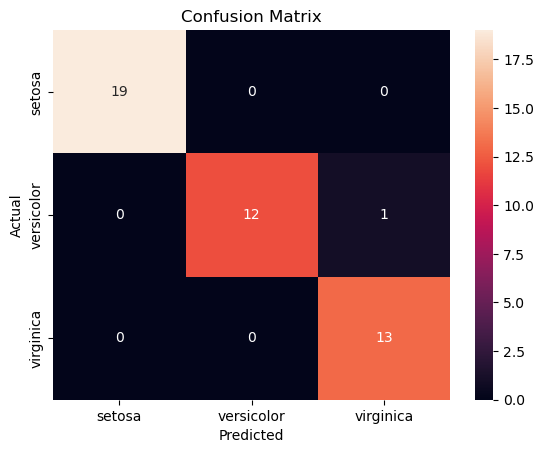

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Sample Class Probabilities (first 5 rows):

[[4.15877025e-088 9.95527834e-001 4.47216553e-003]
 [1.00000000e+000 1.31031120e-013 2.21772081e-020]
 [9.83135514e-285 2.70138384e-012 1.00000000e+000]
 [9.54732794e-092 9.74861432e-001 2.51385679e-002]
 [1.08678364e-103 8.31910709e-001 1.68089291e-001]]


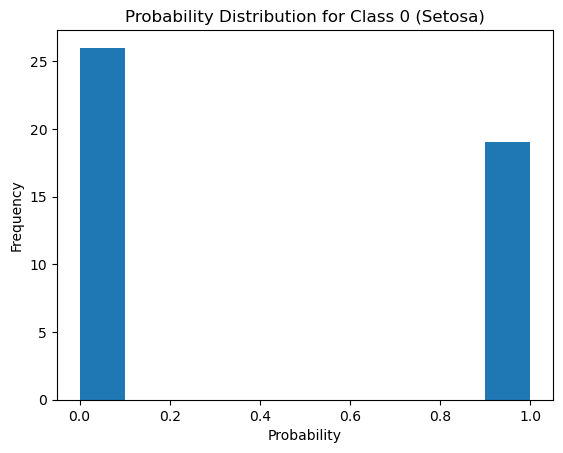

In [50]:
probabilities = gnb.predict_proba(X_test)

print("\nSample Class Probabilities (first 5 rows):\n")
print(probabilities[:5])

# Plot probability distribution for one class
plt.figure()
plt.hist(probabilities[:, 0], bins=10)
plt.title("Probability Distribution for Class 0 (Setosa)")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

In [51]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 1.0


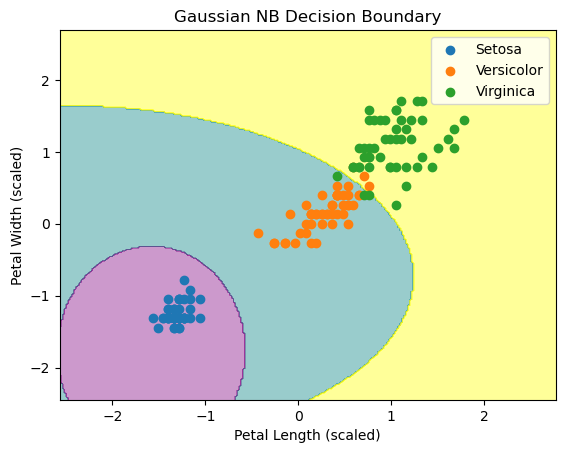

In [52]:
# Decision Boundary (2 Features Only)

X_2 = iris.data[:, 2:4]   # Petal Length & Petal Width
y_2 = iris.target

scaler2 = StandardScaler()
X_2_scaled = scaler2.fit_transform(X_2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2_scaled, y_2, test_size=0.2, random_state=42
)

model2 = GaussianNB()
model2.fit(X_train2, y_train2)

# Mesh grid
h = 0.02
x_min, x_max = X_2_scaled[:, 0].min() - 1, X_2_scaled[:, 0].max() + 1
y_min, y_max = X_2_scaled[:, 1].min() - 1, X_2_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap
plt.figure()


# Background decision boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['purple','teal','yellow']))

# Scatter plot with proper class separation
for i, label in enumerate(['Setosa', 'Versicolor', 'Virginica']):
    plt.scatter(
        X_2_scaled[y_2 == i, 0],
        X_2_scaled[y_2 == i, 1],
        label=label
    )

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Gaussian NB Decision Boundary")
plt.legend()
plt.show()

In [53]:
from sklearn.model_selection import cross_val_score
model = GaussianNB()

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Average Accuracy: 0.9533333333333334
